# Saroma sea ice school 2026
# Beginners section

In this tutorial we will learn:
> 1. How to work with Jupyter notebook.<br />
> 2. Plotting map figures.<br />
> 3. Plotting data from NetCDF file on maps.<br />

<h1 style="text-align: center;">1. How to work with Jupyter notebook</h1>

Jupyter notebook is a useful tool that allows you to write and execute Python programms within a web browser. Using Jupyter Notebook enables you to execute code step by step and display results immediately, as well as include Markdown text alongside your code. This makes it useful for documentation and reporting like these tutorials!

The following is the minimum basic of Jupyter notebook that is necessary for "general.ipynb" tutorial.<br />
First of first, you need to "Shift + Enter" to execute commands. <br />
Place your cursor in the next "cell" (the box next to In [ ]:), and press "Shift + Enter".<br />

In [20]:
print('Hello Sea Ice School!')

Hello Sea Ice School!



If this works, you will see a greeting.

Now let's briefly try some matrix calculations to get used to Python. <br />
First, to work with Python, you always need to import modules.<br />
`Numpy` is a basic module for any calculation. <br />

In [2]:
import numpy as np

Then define a data array "A" as follows. <br />
Note that texts following "#" are ignored from command lines. These are just supporting information for you.

In [5]:
A = np.array([[1,2,3],[7,4,3],[9,5,2]]) # Define an array "A"

In [6]:
A # Show contents in "A"

array([[1, 2, 3],
       [7, 4, 3],
       [9, 5, 2]])

In [7]:
A[0] # Show the first raw in "A"

array([1, 2, 3])

In [8]:
A[1] # Show the second raw in "A"

array([7, 4, 3])

In [9]:
A[2,0] # Show the number at third raw and first column in "A"

9

In [10]:
A[:,0] # Show the first column in "A"

array([1, 7, 9])

In [11]:
A.shape # Check the size of array

(3, 3)

In [13]:
A+2 # Add 3 to all numbers in A

array([[ 3,  4,  5],
       [ 9,  6,  5],
       [11,  7,  4]])

In [12]:
A*2 # Multiply 2 to all numbers in A

array([[ 2,  4,  6],
       [14,  8,  6],
       [18, 10,  4]])

You can multiply different arrays as well.<br />
But be careful that those arrays must have same numbers of raws or columns!

In [15]:
# Define other arrays

B = np.array([[0,1,2],[3,4,5],[6,7,8]]) # ３ raws x ３ columns
C = np.array([3,4,5]) # １ raw x ３ columns
D = np.array([[3],[4],[5]]) # ３ raws x １ column
E = np.array([0,1]) # １ raw x ２ columns

In [16]:
A*B

array([[ 0,  2,  6],
       [21, 16, 15],
       [54, 35, 16]])

In [17]:
A*C

array([[ 3,  8, 15],
       [21, 16, 15],
       [27, 20, 10]])

In [18]:
A*D

array([[ 3,  6,  9],
       [28, 16, 12],
       [45, 25, 10]])

In [19]:
A*E

ValueError: operands could not be broadcast together with shapes (3,3) (2,) 

<h1 style="text-align: center;">2. Plotting map figures</h1>

Now let's plot map figures using `Matplotlib` and `Cartopy` module.

In [22]:
import matplotlib.pyplot as plt # General for all type of plotting
import cartopy # Specifically for map plot
import cartopy.crs as ccrs

Below is the simplest global map plot.

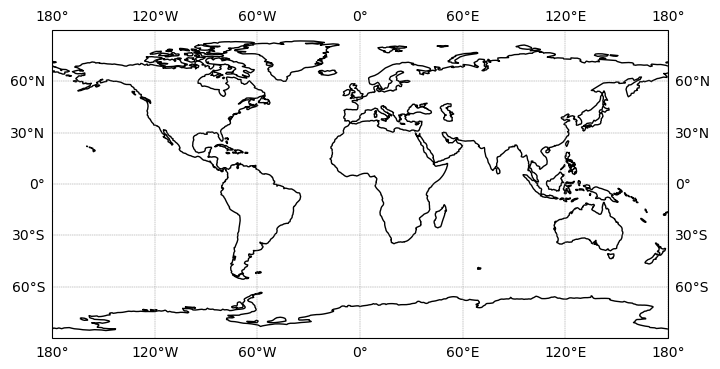

In [32]:
fig = plt.figure(1, figsize=(8,4)) # Figure size (horizontal, vertical)

# Create a map axis using the Plate Carrée projection.
ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree()) 

#This is the map command! i.e. drawing coastlines
ax.coastlines()
# You can use a below line instead.
#ax.add_feature(cartopy.feature.LAND, edgecolor='k', zorder=4, facecolor=(1,1,1,0))

# Gridlines in gray
ax.gridlines(linestyle='--', color='gray', linewidth=0.3, draw_labels=True)

# Display the figure
plt.show()

You can also: <br />
> - focus the region of your interest. <br />
> - add land and ocean colors as you need. <br />

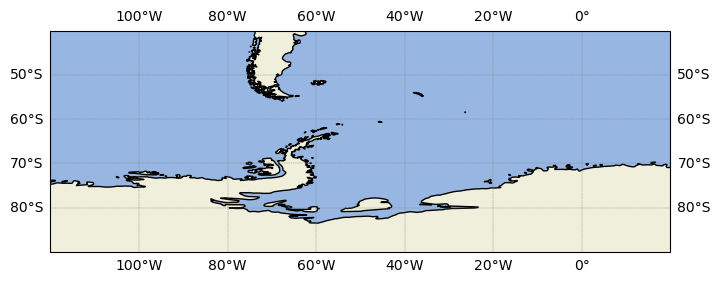

In [38]:
fig = plt.figure(1, figsize=(8,4)) 
ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree()) 
ax.coastlines()
ax.gridlines(linestyle='--', color='gray', linewidth=0.3, draw_labels=True)

# Focus the region of your interest.
ax.set_extent([-120,20,-90,-40], ccrs.PlateCarree()) # Play at your interest!

# Add features on the Earth's surface.
ax.add_feature(cartopy.feature.OCEAN) # Add single color on ocean
ax.add_feature(cartopy.feature.LAND) # Add single color on land

# You can use a below line instead of "OCEAN" or "LAND" features.
#ax.stock_img()

# You can use a below line to draw lands instead of "coastlines" command.
#ax.add_feature(cartopy.feature.LAND, edgecolor='k', zorder=4, facecolor=(1,1,1,0))

plt.show()

More to learn in the "general.ipynb" tutorial later!

<h1 style="text-align: center;">3. Plotting data from NetCDF file on maps</h1>

Let's play with a NetCDF file. <br />

NetCDF is a file format widely used for scientific data, especially in atmospheric and ocean sciences. It stores multi-dimensional data, such as time, latitude, longitude, and height, in a single file. Variables and metadata are included together, which makes the data self-describing and easy to share. <br />

Here we use a NetCDF file extracted from GEOS-Chem output by Sakiko just as an example. <br />
We use `xarray` module to read and process the data.

In [39]:
import xarray as xr

In [44]:
# Read the data with xarray
#ds = xr.open_dataset('GEOS-Chem_v12.9.3_2017_CIce2C.nc') 
ds = xr.open_dataset('../data/GEOS-Chem_v12.9.3_2017_CIce2C.nc') 

In [45]:
ds # Show metadata

<xarray.Dataset> Size: 38MB
Dimensions:  (time: 12, lat: 46, lon: 72, lev: 30)
Coordinates:
  * time     (time) datetime64[ns] 96B 2017-01-01 2017-02-01 ... 2017-12-01
  * lat      (lat) float32 184B -89.0 -86.0 -82.0 -78.0 ... 78.0 82.0 86.0 89.0
  * lon      (lon) float32 288B -180.0 -175.0 -170.0 ... 165.0 170.0 175.0
  * lev      (lev) float32 120B 0.9925 0.9775 0.9625 ... 0.3128 0.2665 0.2265
Data variables:
    SALA     (time, lev, lat, lon) float32 5MB ...
    SALC     (time, lev, lat, lon) float32 5MB ...
    DMS      (time, lev, lat, lon) float32 5MB ...
    MSA      (time, lev, lat, lon) float32 5MB ...
    SO4      (time, lev, lat, lon) float32 5MB ...
    O3       (time, lev, lat, lon) float32 5MB ...
    CH4      (time, lev, lat, lon) float32 5MB ...
    CO       (time, lev, lat, lon) float32 5MB ...
Attributes:
    description:  Atmospheric Composition simulated by GEOS-Chem v12.9.3 for ...
    history:      Created 2026-02-09 16:46:59

In [46]:
ds['SALA'] # Read a specific variable.

<xarray.DataArray 'SALA' (time: 12, lev: 30, lat: 46, lon: 72)> Size: 5MB
[1192320 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 96B 2017-01-01 2017-02-01 ... 2017-12-01
  * lat      (lat) float32 184B -89.0 -86.0 -82.0 -78.0 ... 78.0 82.0 86.0 89.0
  * lon      (lon) float32 288B -180.0 -175.0 -170.0 ... 165.0 170.0 175.0
  * lev      (lev) float32 120B 0.9925 0.9775 0.9625 ... 0.3128 0.2665 0.2265
Attributes:
    units:      ppbv
    long_name:  Sea salt in fine mode

In [49]:
ds['lon'] # You can also read coordinates data.

<xarray.DataArray 'lon' (lon: 72)> Size: 288B
array([-180., -175., -170., -165., -160., -155., -150., -145., -140., -135.,
       -130., -125., -120., -115., -110., -105., -100.,  -95.,  -90.,  -85.,
        -80.,  -75.,  -70.,  -65.,  -60.,  -55.,  -50.,  -45.,  -40.,  -35.,
        -30.,  -25.,  -20.,  -15.,  -10.,   -5.,    0.,    5.,   10.,   15.,
         20.,   25.,   30.,   35.,   40.,   45.,   50.,   55.,   60.,   65.,
         70.,   75.,   80.,   85.,   90.,   95.,  100.,  105.,  110.,  115.,
        120.,  125.,  130.,  135.,  140.,  145.,  150.,  155.,  160.,  165.,
        170.,  175.], dtype=float32)
Coordinates:
  * lon      (lon) float32 288B -180.0 -175.0 -170.0 ... 165.0 170.0 175.0
Attributes:
    units:      degrees_east
    long_name:  Longitude
    var_desc:   lon

NOTE: Vertical grid in GEOS-Chem is defined with "sigma height", i.e. relative to surface pressure. This means the vertical levels follow the terrain instead of fixed altitudes (km) or pressures (hPa). Each sigma level roughly corresponds to a pressure level, and we can convert it to pressure or altitude if needed. <br />
Here is the approximate altitude and pressure values at each level: <br />
https://geos-chem.readthedocs.io/en/latest/supplemental-guides/vertical-grids.html <br />
Here I extracted the data up to level = 30, approximately corresponding to the troposphere (~ 10 km).

In [50]:
ds['lev'] # NOTE!

<xarray.DataArray 'lev' (lev: 30)> Size: 120B
array([0.9925  , 0.9775  , 0.9625  , 0.9475  , 0.9325  , 0.9175  , 0.9025  ,
       0.8875  , 0.8725  , 0.8575  , 0.8425  , 0.8275  , 0.81    , 0.7875  ,
       0.7625  , 0.7375  , 0.7125  , 0.6875  , 0.65625 , 0.61875 , 0.58125 ,
       0.54375 , 0.50625 , 0.46875 , 0.43125 , 0.39375 , 0.35625 , 0.312792,
       0.266479, 0.226514], dtype=float32)
Coordinates:
  * lev      (lev) float32 120B 0.9925 0.9775 0.9625 ... 0.3128 0.2665 0.2265

You can easily select the data from the specific grid using `sel` function. <br />
More advanced use of `sel` shows up in "general.ipynb".

In [54]:
ds['SALA'].sel(time='2017-01-01', lat='-50', lon='-105') # Select data.

<xarray.DataArray 'SALA' (lev: 30)> Size: 120B
[30 values with dtype=float32]
Coordinates:
    time     datetime64[ns] 8B 2017-01-01
    lat      float32 4B -50.0
    lon      float32 4B -105.0
  * lev      (lev) float32 120B 0.9925 0.9775 0.9625 ... 0.3128 0.2665 0.2265
Attributes:
    units:      ppbv
    long_name:  Sea salt in fine mode

In [55]:
ds['SALA'].sel(time='2017-01-01', lat='-50', lon='-105').values # Show the selected data.

array([0.7225814 , 0.696992  , 0.66578335, 0.6193584 , 0.5687032 ,
       0.5204455 , 0.46795222, 0.38902718, 0.3000858 , 0.2348688 ,
       0.18174426, 0.13913266, 0.10358543, 0.07548507, 0.05065848,
       0.03617544, 0.02659886, 0.01959693, 0.01574067, 0.01248767,
       0.01094827, 0.00959893, 0.00877957, 0.00798908, 0.00715279,
       0.00616397, 0.00524014, 0.00407293, 0.00287916, 0.0017955 ],
      dtype=float32)

**Plot data on map!**

In this example, you plot: <br />
> - Sea salt in fine mode ("SALA" in ppbv) <br />
> - Time = January <br />
> - Level = 0, lowest model level (~ 100 m) <br />


You can play more by changing: <br />
> - variables other than SALA <br />
> - "vmin" and "vmax" <br />
> - "time" (from January to December) and "lev" (up to 30) <br />
> - lat & lon extent
> - "cmap" into other colormap available in Python <br />


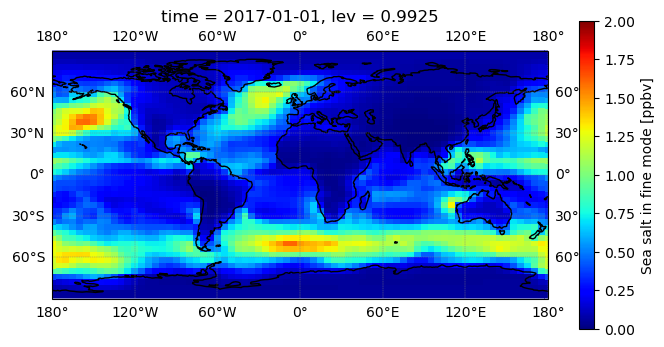

In [64]:
fig = plt.figure(1, figsize=(8,4))
ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
ax.coastlines()
ax.gridlines(linestyle='--', color='gray', linewidth=0.3, draw_labels=True)

# Plot data on map
ds['SALA'].sel(time='2017-01-01').isel(lev=0).plot(cmap='jet', vmin=0, vmax=2, transform=ccrs.PlateCarree()) 
# You can also plot time averaged (annual mean) values as follows.
#ds['SALA'].isel(lev=0).mean('time').plot(cmap='jet', vmin=0, vmax=2, transform=ccrs.PlateCarree()) 

## Focus the region of your interest.
#ax.set_extent([-120,20,-90,-40], ccrs.PlateCarree())

plt.show()

<h1 style="text-align: center;">----- Beginners section ends -----</h1>

Now you are ready to step into general section! <br />
Enjoy more advanced, online use of NetCDF data from CMIP6 output!